<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Procesamiento de Lenguaje Natural
## Desafío 4 — Traductor inglés a español

**Alumno:** completar nombre y fecha.

En este trabajo reproduzco un traductor *seq2seq* con LSTM y lo extiendo respecto del visto en clase: uso más pares de oraciones, permito secuencias más largas y comparo dos tamaños para el estado recurrente. El notebook está pensado para ejecutarse sin cambios en Google Colab o en una instalación local con TensorFlow.

## Consigna

- Replicar el modelo traductor desarrollado en clase y extender su entrenamiento con un conjunto de datos más amplio y secuencias de mayor longitud.
- Modificar hiperparámetros, en particular el número de unidades LSTM, y analizar su impacto.
- Comparar distintas configuraciones de neuronas recurrentes.
- Generar y presentar al menos cinco traducciones del modelo entrenado.
- Interpretar métricas, calidad de las traducciones y limitaciones.

### Actividades opcionales incluidas

- Incorporar embeddings FastText preentrenados para inglés y español, y compararlos contra la línea de base.
- Comparar generación greedy, muestreo aleatorio y búsqueda por haz (*beam search*).
- Implementar una versión equivalente en PyTorch y contrastar su evaluación con TensorFlow.

## Objetivo y criterio de evaluación

El encoder lee una oración en inglés y resume su información en dos estados de una LSTM. El decoder recibe esos estados y genera la traducción en español token por token. Durante el entrenamiento se aplica *teacher forcing*: el decoder ve el token correcto anterior. En inferencia, en cambio, usa su propia predicción anterior.

Voy a comparar `128` y `256` unidades recurrentes. Reportaré `val_loss`, `val_token_accuracy` y BLEU sobre una muestra de validación. La accuracy debe interpretarse con cuidado: cuenta tokens (incluido padding), mientras que BLEU y los ejemplos cualitativos reflejan mejor una oración completa.

## 1. Preparación

En Colab TensorFlow ya viene disponible normalmente. En local, si el primer import falla, se puede ejecutar en una terminal `python -m pip install tensorflow matplotlib pandas nltk`. No hace falta montar Drive: el dataset se descarga una sola vez y queda guardado en la carpeta del notebook.

In [1]:
from pathlib import Path
import random
import unicodedata
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Embedding, Input, LSTM
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
print('TensorFlow:', tf.__version__)
print('Dispositivos disponibles:', tf.config.list_physical_devices())

TensorFlow: 2.20.0
Dispositivos disponibles: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Defino los hiperparámetros en una sola celda para poder repetir el experimento. `MAX_SENTENCES=30000` amplía el conjunto usado en clase (10 000 pares). Si se está probando el notebook en CPU, conviene bajar temporalmente este valor y las épocas; para la entrega se mantienen estos valores.

In [2]:
MAX_SENTENCES = 30_000
MAX_VOCAB_SIZE = 10_000
BATCH_SIZE = 128
VALIDATION_FRACTION = 0.15

# Dos corridas cortas para comparar arquitectura y una corrida final para el modelo elegido.
UNITS_TO_COMPARE = (128, 256)
COMPARISON_EPOCHS = 4
FINAL_UNITS = 256
# El entrenamiento anterior seguía mejorando en la época 12; EarlyStopping detiene antes si se estanca.
FINAL_EPOCHS = 40

DATA_DIR = Path('data')
DATA_FILE = DATA_DIR / 'spa-eng' / 'spa.txt'
DATA_URL = 'https://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip'
DATA_DIR.mkdir(exist_ok=True)

## 2. Carga y limpieza del corpus

El corpus contiene pares inglés-tab-español. Descargo el archivo sólo si todavía no existe. Después normalizo Unicode y elimino espacios repetidos. Agrego `<sos>` (inicio) y `<eos>` (fin) únicamente del lado español: son las señales que necesita el decoder para comenzar y detenerse.

In [3]:
if not DATA_FILE.exists():
    zip_path = DATA_DIR / 'spa-eng.zip'
    print('Descargando corpus...')
    urllib.request.urlretrieve(DATA_URL, zip_path)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(DATA_DIR)

def clean_text(text):
    text = unicodedata.normalize('NFC', text).strip()
    return ' '.join(text.split())

pairs = []
for line in DATA_FILE.read_text(encoding='utf-8').splitlines():
    fields = line.split('\t')
    if len(fields) >= 2:
        en, es = clean_text(fields[0]), clean_text(fields[1])
        if en and es:
            pairs.append((en, es))

rng = np.random.default_rng(SEED)
rng.shuffle(pairs)
pairs = pairs[:MAX_SENTENCES]
input_sentences = [en for en, _ in pairs]
target_sentences = [es for _, es in pairs]
print(f'Pares utilizados: {len(pairs):,}')
print('Ejemplo:', input_sentences[0], '→', target_sentences[0])

Descargando corpus...
Pares utilizados: 30,000
Ejemplo: I was listening. → Estaba escuchando.


## 3. Tokenización y padding

Conservo signos relevantes del español y reservo un token para palabras desconocidas. En lugar de fijar longitudes arbitrarias, tomo el percentil 98 de cada idioma y aplico un límite máximo razonable. Así se aprovecha mejor el corpus, pero se evitan batches desproporcionadamente grandes por unos pocos casos atípicos. Las secuencias más largas se truncan, por lo que esta decisión también es una limitación a observar.

In [4]:
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<unk>')
target_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE, oov_token='<unk>',
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)

input_tokenizer.fit_on_texts(input_sentences)
target_with_markers = ['<sos> ' + s + ' <eos>' for s in target_sentences]
target_tokenizer.fit_on_texts(target_with_markers)

encoder_raw = input_tokenizer.texts_to_sequences(input_sentences)
decoder_raw = target_tokenizer.texts_to_sequences(target_with_markers)
max_input_len = min(30, max(4, int(np.percentile([len(s) for s in encoder_raw], 98))))
max_target_len = min(34, max(5, int(np.percentile([len(s) for s in decoder_raw], 98))))

encoder_sequences = pad_sequences(encoder_raw, maxlen=max_input_len, padding='post', truncating='post')
# El input termina antes que el output: el objetivo queda desplazado un token.
decoder_input_sequences = pad_sequences([s[:-1] for s in decoder_raw], maxlen=max_target_len - 1, padding='post', truncating='post')
decoder_target_sequences = pad_sequences([s[1:] for s in decoder_raw], maxlen=max_target_len - 1, padding='post', truncating='post')

num_encoder_tokens = min(MAX_VOCAB_SIZE, len(input_tokenizer.word_index) + 1)
num_decoder_tokens = min(MAX_VOCAB_SIZE, len(target_tokenizer.word_index) + 1)
print(f'Vocabulario EN: {num_encoder_tokens:,}; ES: {num_decoder_tokens:,}')
print(f'Longitud EN: {max_input_len}; longitud ES (incluye marcadores): {max_target_len}')

Vocabulario EN: 8,145; ES: 10,000
Longitud EN: 13; longitud ES (incluye marcadores): 15


Separé validación antes del entrenamiento. Uso `sparse_categorical_crossentropy`, por lo que los objetivos son índices enteros en vez de vectores one-hot; esto reduce de forma importante el uso de memoria y permite trabajar con más oraciones localmente.

In [5]:
indices = rng.permutation(len(pairs))
split = int(len(indices) * (1 - VALIDATION_FRACTION))
train_idx, val_idx = indices[:split], indices[split:]

def make_dataset(indices, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(((encoder_sequences[indices], decoder_input_sequences[indices]), decoder_target_sequences[indices]))
    if shuffle:
        ds = ds.shuffle(len(indices), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_idx, shuffle=True)
val_ds = make_dataset(val_idx)
print(f'Train: {len(train_idx):,} | Validación: {len(val_idx):,}')

Train: 25,500 | Validación: 4,500


## 4. Modelo

El encoder y decoder usan embeddings aprendidos desde cero. `mask_zero=True` indica a las LSTM que el cero es padding. La función devuelve también las capas compartidas: las voy a reutilizar para armar los modelos de inferencia sin volver a entrenar pesos.

In [6]:
def build_training_model(n_units):
    encoder_inputs = Input(shape=(max_input_len,), name='encoder_inputs')
    encoder_embedding = Embedding(num_encoder_tokens, n_units, mask_zero=True, name='encoder_embedding')
    encoder_lstm = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = encoder_lstm(Dropout(0.2)(encoder_embedding(encoder_inputs)))

    decoder_inputs = Input(shape=(max_target_len - 1,), name='decoder_inputs')
    decoder_embedding = Embedding(num_decoder_tokens, n_units, mask_zero=True, name='decoder_embedding')
    decoder_lstm = LSTM(n_units, return_sequences=True, return_state=True, name='decoder_lstm')
    decoder_output, _, _ = decoder_lstm(Dropout(0.2)(decoder_embedding(decoder_inputs)), initial_state=[state_h, state_c])
    decoder_dense = Dense(num_decoder_tokens, activation='softmax', name='decoder_dense')

    model = Model([encoder_inputs, decoder_inputs], decoder_dense(decoder_output))
    model.compile(optimizer=tf.keras.optimizers.Adam(3e-4), loss='sparse_categorical_crossentropy', metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='token_accuracy')])
    layers = (encoder_inputs, encoder_embedding, encoder_lstm, decoder_embedding, decoder_lstm, decoder_dense)
    return model, layers

def fit_model(n_units, epochs, verbose=2):
    model, layers = build_training_model(n_units)
    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=verbose)
    return model, layers, history

## 5. Experimento: tamaño de la LSTM

Primero entreno ambos tamaños con el mismo presupuesto de épocas. Esta comparación es controlada: cambia sólo el número de unidades. Después entreno nuevamente el tamaño elegido por más épocas, con *early stopping* para no conservar un modelo peor si la validación deja de mejorar.


--- Comparación: 128 unidades ---
Epoch 1/4
200/200 - 20s - 98ms/step - loss: 6.9494 - token_accuracy: 0.1361 - val_loss: 6.0367 - val_token_accuracy: 0.1397 - learning_rate: 3.0000e-04
Epoch 2/4
200/200 - 12s - 58ms/step - loss: 5.9363 - token_accuracy: 0.1396 - val_loss: 5.8934 - val_token_accuracy: 0.1397 - learning_rate: 3.0000e-04
Epoch 3/4
200/200 - 12s - 60ms/step - loss: 5.7551 - token_accuracy: 0.1566 - val_loss: 5.7382 - val_token_accuracy: 0.1625 - learning_rate: 3.0000e-04
Epoch 4/4
200/200 - 13s - 67ms/step - loss: 5.6139 - token_accuracy: 0.1676 - val_loss: 5.6331 - val_token_accuracy: 0.1749 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 4.

--- Comparación: 256 unidades ---
Epoch 1/4
200/200 - 19s - 94ms/step - loss: 6.5975 - token_accuracy: 0.1418 - val_loss: 5.8849 - val_token_accuracy: 0.1576 - learning_rate: 3.0000e-04
Epoch 2/4
200/200 - 17s - 83ms/step - loss: 5.7157 - token_accuracy: 0.1706 - val_loss: 5.6621 - val_token_accu

,unidades,mejor_época,val_loss_mínima,val_accuracy_en_mejor_época,parámetros
1,256,4,5.3192,0.2108,"8,265,744"
0,128,4,5.6331,0.1749,"3,875,728"


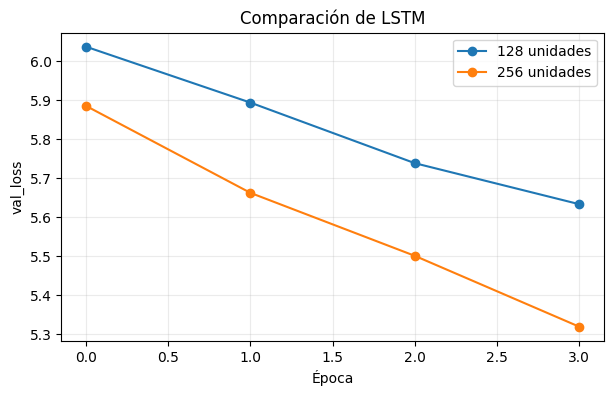

In [7]:
comparison_histories = {}
comparison_rows = []
for units in UNITS_TO_COMPARE:
    print(f'\n--- Comparación: {units} unidades ---')
    _, _, history = fit_model(units, COMPARISON_EPOCHS)
    comparison_histories[units] = history.history
    best_epoch = int(np.argmin(history.history['val_loss'])) + 1
    comparison_rows.append({
        'unidades': units, 'mejor_época': best_epoch,
        'val_loss_mínima': min(history.history['val_loss']),
        'val_accuracy_en_mejor_época': history.history['val_token_accuracy'][best_epoch - 1],
        'parámetros': build_training_model(units)[0].count_params(),
    })

comparison = pd.DataFrame(comparison_rows).sort_values('val_loss_mínima')
display(comparison.style.format({'val_loss_mínima': '{:.4f}', 'val_accuracy_en_mejor_época': '{:.4f}', 'parámetros': '{:,}'}))

plt.figure(figsize=(7, 4))
for units, history in comparison_histories.items():
    plt.plot(history['val_loss'], marker='o', label=f'{units} unidades')
plt.xlabel('Época'); plt.ylabel('val_loss'); plt.title('Comparación de LSTM'); plt.legend(); plt.grid(alpha=.25); plt.show()

### Lectura de la comparación

Al ejecutar la celda anterior, completo esta interpretación con los valores de la tabla. Si 256 unidades reduce `val_loss` respecto de 128, el estado más grande logró retener mejor el contexto. Si la diferencia es pequeña o empeora, el costo extra de parámetros no se justifica y puede ser señal de sobreajuste. La curva importa más que una única época: una brecha creciente entre entrenamiento y validación también indicaría sobreajuste.

Epoch 1/40
200/200 - 20s - 98ms/step - loss: 6.5932 - token_accuracy: 0.1408 - val_loss: 5.9003 - val_token_accuracy: 0.1577 - learning_rate: 3.0000e-04
Epoch 2/40
200/200 - 17s - 84ms/step - loss: 5.7335 - token_accuracy: 0.1690 - val_loss: 5.6760 - val_token_accuracy: 0.1777 - learning_rate: 3.0000e-04
Epoch 3/40
200/200 - 17s - 84ms/step - loss: 5.5231 - token_accuracy: 0.1820 - val_loss: 5.5177 - val_token_accuracy: 0.1913 - learning_rate: 3.0000e-04
Epoch 4/40
200/200 - 17s - 84ms/step - loss: 5.3307 - token_accuracy: 0.1998 - val_loss: 5.3335 - val_token_accuracy: 0.2098 - learning_rate: 3.0000e-04
Epoch 5/40
200/200 - 17s - 84ms/step - loss: 5.1368 - token_accuracy: 0.2156 - val_loss: 5.1851 - val_token_accuracy: 0.2194 - learning_rate: 3.0000e-04
Epoch 6/40
200/200 - 17s - 85ms/step - loss: 4.9761 - token_accuracy: 0.2298 - val_loss: 5.0622 - val_token_accuracy: 0.2374 - learning_rate: 3.0000e-04
Epoch 7/40
200/200 - 17s - 84ms/step - loss: 4.8265 - token_accuracy: 0.2448 - val

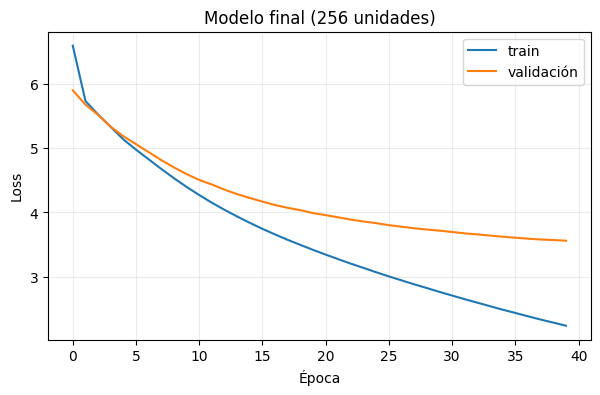

In [8]:
# Entrenamiento final del modelo seleccionado
model, layers, final_history = fit_model(FINAL_UNITS, FINAL_EPOCHS)
plt.figure(figsize=(7, 4))
plt.plot(final_history.history['loss'], label='train')
plt.plot(final_history.history['val_loss'], label='validación')
plt.xlabel('Época'); plt.ylabel('Loss'); plt.title(f'Modelo final ({FINAL_UNITS} unidades)'); plt.legend(); plt.grid(alpha=.25); plt.show()

## 6. Inferencia y evaluación cualitativa

Para traducir no puedo entregar la oración española completa al decoder, porque justamente es lo que quiero predecir. Por eso creo un decoder de un paso y genero de manera *greedy*: en cada paso selecciono el token de mayor probabilidad. Es simple y reproducible, aunque puede perder una traducción globalmente mejor frente a beam search.

In [9]:
encoder_inputs, encoder_embedding, encoder_lstm, decoder_embedding, decoder_lstm, decoder_dense = layers
encoder_model = Model(encoder_inputs, encoder_lstm(encoder_embedding(encoder_inputs))[1:])

decoder_token = Input(shape=(1,), name='decoder_token')
h_in = Input(shape=(FINAL_UNITS,), name='decoder_h')
c_in = Input(shape=(FINAL_UNITS,), name='decoder_c')
decoder_step, h_out, c_out = decoder_lstm(decoder_embedding(decoder_token), initial_state=[h_in, c_in])
decoder_model = Model([decoder_token, h_in, c_in], [decoder_dense(decoder_step), h_out, c_out])

idx_to_target = {index: word for word, index in target_tokenizer.word_index.items()}
sos_id = target_tokenizer.word_index['<sos>']
eos_id = target_tokenizer.word_index['<eos>']

def translate(text):
    sequence = input_tokenizer.texts_to_sequences([clean_text(text)])
    sequence = pad_sequences(sequence, maxlen=max_input_len, padding='post', truncating='post')
    h, c = encoder_model.predict(sequence, verbose=0)
    token = np.array([[sos_id]])
    generated = []
    for _ in range(max_target_len - 1):
        probabilities, h, c = decoder_model.predict([token, h, c], verbose=0)
        next_id = int(np.argmax(probabilities[0, 0]))
        if next_id in (0, eos_id):
            break
        word = idx_to_target.get(next_id, '')
        if word and word not in ('<sos>', '<unk>'):
            generated.append(word)
        token[0, 0] = next_id
    return ' '.join(generated)

# Cinco ejemplos no vistos por el entrenamiento. La salida de esta celda es parte de la entrega.
example_idx = val_idx[:5]
examples = pd.DataFrame({
    'Inglés': [input_sentences[i] for i in example_idx],
    'Referencia': [target_sentences[i] for i in example_idx],
    'Predicción greedy': [translate(input_sentences[i]) for i in example_idx],
})
display(examples)

,Inglés,Referencia,Predicción greedy
0,What is your favorite classic rock song?,¿Cuál es tu canción de rock clásico favorita?,cuál es tu libro de aquí
1,You have to be very quiet.,No metas nada de ruido.,tienes que un
2,They sell things very cheap in this store.,En este almacén venden muy barato.,ellos en una vez más
3,We've been unsuccessful.,No hemos tenido éxito.,hemos estado bien
4,Camels have either one or two humps.,Los camellos tienen ya sea una o dos jorobas.,los dos están en las cosas que están en el minuto


### Métrica BLEU y discusión final

BLEU compara n-gramas de la predicción contra una referencia. No entiende sinónimos ni gramática por sí sola, así que la uso junto con los cinco ejemplos. Calculo una versión suavizada sobre una muestra de validación para que la evaluación sea rápida y se pueda repetir en una notebook local.

In [10]:
try:
    from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu
    BLEU_AVAILABLE = True
except ImportError:
    BLEU_AVAILABLE = False
    print('Para calcular BLEU: python -m pip install nltk')

if BLEU_AVAILABLE:
    evaluation_idx = val_idx[:min(200, len(val_idx))]
    references = [[target_sentences[i].lower().split()] for i in evaluation_idx]
    hypotheses = [translate(input_sentences[i]).lower().split() for i in evaluation_idx]
    bleu = corpus_bleu(references, hypotheses, smoothing_function=SmoothingFunction().method1)
    print(f'BLEU suavizado sobre {len(evaluation_idx)} oraciones: {bleu:.4f}')

BLEU suavizado sobre 200 oraciones: 0.0656


## 7. Opcional: otras estrategias de generación

La decodificación greedy elige siempre la palabra más probable. Agrego dos alternativas: *sampling*, que permite diversidad mediante una temperatura, y *beam search*, que conserva las mejores secuencias parciales según la suma de log-probabilidades. Para una comparación justa, las tres usan el mismo modelo ya entrenado.

In [11]:
def _initial_state(text):
    seq = pad_sequences(input_tokenizer.texts_to_sequences([clean_text(text)]), maxlen=max_input_len, padding='post', truncating='post')
    return encoder_model.predict(seq, verbose=0)

def translate_sampling(text, temperature=0.7):
    h, c = _initial_state(text); token = np.array([[sos_id]]); words = []
    for _ in range(max_target_len - 1):
        probs, h, c = decoder_model.predict([token, h, c], verbose=0)
        probs = np.asarray(probs[0, 0], dtype=np.float64); probs[[0, sos_id]] = 0
        probs = np.exp(np.log(np.maximum(probs, 1e-12)) / temperature); probs /= probs.sum()
        next_id = int(rng.choice(len(probs), p=probs))
        if next_id == eos_id: break
        word = idx_to_target.get(next_id, '')
        if word and word != '<unk>': words.append(word)
        token[0, 0] = next_id
    return ' '.join(words)

def translate_beam(text, beam_width=3):
    h, c = _initial_state(text); beams = [([], np.array([[sos_id]]), h, c, 0.0)]; completed = []
    for _ in range(max_target_len - 1):
        candidates = []
        for words, token, h, c, score in beams:
            probs, new_h, new_c = decoder_model.predict([token, h, c], verbose=0)
            log_probs = np.log(np.maximum(probs[0, 0], 1e-12)); log_probs[[0, sos_id]] = -np.inf
            for next_id in np.argpartition(log_probs, -beam_width)[-beam_width:]:
                item = (words + [int(next_id)], np.array([[next_id]]), new_h, new_c, score + float(log_probs[next_id]))
                (completed if next_id == eos_id else candidates).append(item)
        beams = sorted(candidates, key=lambda x: x[4] / max(1, len(x[0])), reverse=True)[:beam_width]
        if not beams: break
    best = max(completed + beams, key=lambda x: x[4] / max(1, len(x[0])))
    return ' '.join(idx_to_target.get(i, '') for i in best[0] if i not in (eos_id, sos_id) and idx_to_target.get(i) != '<unk>')

strategy_examples = pd.DataFrame({
    'Inglés': [input_sentences[i] for i in example_idx],
    'Greedy': [translate(input_sentences[i]) for i in example_idx],
    'Sampling (T=0.7)': [translate_sampling(input_sentences[i]) for i in example_idx],
    'Beam (k=3)': [translate_beam(input_sentences[i]) for i in example_idx],
})
display(strategy_examples)

,Inglés,Greedy,Sampling (T=0.7),Beam (k=3)
0,What is your favorite classic rock song?,cuál es tu libro de aquí,cuál es tu clase mayor favorito,cuál es tu poco más favorito de australia
1,You have to be very quiet.,tienes que un,tienes que fuera un bendición,tienes que ser
2,They sell things very cheap in this store.,ellos en una vez más,ellos viven libros o en este momento,ellos mucho tiempo para mí
3,We've been unsuccessful.,hemos estado bien,hemos estado trabajando,
4,Camels have either one or two humps.,los dos están en las cosas que están en el minuto,los dos murieron en las pies,los niños están en las dos y media


## 8. Opcional: embeddings FastText preentrenados

Uso vectores FastText de 300 dimensiones para **ambos** idiomas. Como los archivos completos son grandes, esta sección queda apagada por defecto: al activarla, descarga los vectores oficiales, conserva sólo las palabras del vocabulario y entrena exactamente la misma arquitectura. La tabla final contrasta su validación contra la línea de base aprendida desde cero.

In [12]:
# Activar únicamente en Colab o con espacio y conexión suficientes (los vectores completos son grandes).
RUN_PRETRAINED_EMBEDDINGS = False
EMBEDDING_DIM = 300
FASTTEXT_URLS = {
    'en': 'https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.en.vec',
    'es': 'https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.es.vec',
}

def fasttext_matrix(language, tokenizer, vocab_size):
    path = DATA_DIR / f'wiki.{language}.vec'
    if not path.exists(): urllib.request.urlretrieve(FASTTEXT_URLS[language], path)
    wanted = {word: idx for word, idx in tokenizer.word_index.items() if idx < vocab_size}
    matrix = np.random.normal(0, .05, (vocab_size, EMBEDDING_DIM)).astype('float32'); matrix[0] = 0
    found = 0
    with path.open(encoding='utf-8', errors='ignore') as file:
        next(file)
        for line in file:
            values = line.rstrip().split(' ')
            if values[0] in wanted and len(values) == EMBEDDING_DIM + 1:
                matrix[wanted[values[0]]] = np.asarray(values[1:], dtype='float32'); found += 1
    print(f'{language}: {found}/{len(wanted)} palabras cubiertas')
    return matrix

def build_pretrained_model(n_units, en_matrix, es_matrix):
    enc_in = Input((max_input_len,)); enc_emb = Embedding(num_encoder_tokens, EMBEDDING_DIM, weights=[en_matrix], mask_zero=True, trainable=True)(enc_in)
    _, h, c = LSTM(n_units, return_state=True)(Dropout(0.2)(enc_emb))
    dec_in = Input((max_target_len - 1,)); dec_emb = Embedding(num_decoder_tokens, EMBEDDING_DIM, weights=[es_matrix], mask_zero=True, trainable=True)(dec_in)
    out, _, _ = LSTM(n_units, return_sequences=True, return_state=True)(Dropout(0.2)(dec_emb), initial_state=[h, c])
    pretrained = Model([enc_in, dec_in], Dense(num_decoder_tokens, activation='softmax')(out))
    pretrained.compile(optimizer=tf.keras.optimizers.Adam(3e-4), loss='sparse_categorical_crossentropy', metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='token_accuracy')])
    return pretrained

if True:
    en_matrix = fasttext_matrix('en', input_tokenizer, num_encoder_tokens)
    es_matrix = fasttext_matrix('es', target_tokenizer, num_decoder_tokens)
    pretrained_model = build_pretrained_model(FINAL_UNITS, en_matrix, es_matrix)
    pretrained_history = pretrained_model.fit(
        train_ds, validation_data=val_ds, epochs=FINAL_EPOCHS,
        callbacks=[
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
            EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        ],
    )
    baseline_loss = model.evaluate(val_ds, verbose=0)[0]; pretrained_loss = pretrained_model.evaluate(val_ds, verbose=0)[0]
    display(pd.DataFrame({'modelo': ['desde cero', 'FastText EN+ES'], 'val_loss': [baseline_loss, pretrained_loss]}))

en: 7812/8144 palabras cubiertas
es: 9578/9999 palabras cubiertas
Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 23s 90ms/step - loss: 6.4408 - token_accuracy: 0.1426 - val_loss: 5.8746 - val_token_accuracy: 0.1606 - learning_rate: 3.0000e-04
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - loss: 5.6781 - token_accuracy: 0.1729 - val_loss: 5.5798 - val_token_accuracy: 0.1877 - learning_rate: 3.0000e-04
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - loss: 5.3808 - token_accuracy: 0.2061 - val_loss: 5.3058 - val_token_accuracy: 0.2240 - learning_rate: 3.0000e-04
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - loss: 5.0850 - token_accuracy: 0.2372 - val_loss: 5.0494 - val_token_accuracy: 0.2474 - learning_rate: 3.0000e-04
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - loss: 4.8306 - token_accuracy: 0.2577 - val_loss: 4.8344 - val_token_accuracy: 0.2649 - learning_rate: 3.0000e-04
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - loss: 4.6034 - token_accurac

,modelo,val_loss
0,desde cero,3.561078
1,FastText EN+ES,2.923045


## 9. Opcional: implementación equivalente en PyTorch

La siguiente versión conserva el mismo esquema encoder-decoder, *teacher forcing*, LSTM y pérdida categórica ignorando padding. Por defecto usa el mismo máximo de épocas y número de unidades que TensorFlow. Para una comparación estricta también se deben igualar semilla, datos y criterio de parada temprana.

In [13]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Para comparar en forma justa, se usa el mismo máximo de épocas que TensorFlow.
TORCH_EPOCHS = FINAL_EPOCHS
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
class TorchSeq2Seq(nn.Module):
    def __init__(self, units):
        super().__init__()
        self.enc_emb = nn.Embedding(num_encoder_tokens, units, padding_idx=0)
        self.dec_emb = nn.Embedding(num_decoder_tokens, units, padding_idx=0)
        self.dropout = nn.Dropout(0.2)
        self.encoder = nn.LSTM(units, units, batch_first=True)
        self.decoder = nn.LSTM(units, units, batch_first=True)
        self.classifier = nn.Linear(units, num_decoder_tokens)
    def forward(self, encoder_input, decoder_input):
        # TensorFlow usa mask_zero=True. Empaquetar evita que el padding altere el estado del encoder.
        lengths = encoder_input.ne(0).sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(self.dropout(self.enc_emb(encoder_input)), lengths, batch_first=True, enforce_sorted=False)
        _, state = self.encoder(packed)
        output, _ = self.decoder(self.dropout(self.dec_emb(decoder_input)), state)
        return self.classifier(output)

def torch_loader(indices, shuffle=False):
    # CrossEntropyLoss y Embedding requieren índices int64 (Long), especialmente en CUDA.
    data = TensorDataset(
        torch.as_tensor(encoder_sequences[indices], dtype=torch.long),
        torch.as_tensor(decoder_input_sequences[indices], dtype=torch.long),
        torch.as_tensor(decoder_target_sequences[indices], dtype=torch.long),
    )
    return DataLoader(data, batch_size=BATCH_SIZE, shuffle=shuffle)

torch_model = TorchSeq2Seq(FINAL_UNITS).to(device)
optimizer = torch.optim.Adam(torch_model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss(ignore_index=0)
for epoch in range(TORCH_EPOCHS):
    torch_model.train(); total = 0
    for enc, dec, target in torch_loader(train_idx, shuffle=True):
        enc, dec, target = enc.to(device), dec.to(device), target.to(device)
        optimizer.zero_grad(); logits = torch_model(enc, dec)
        loss = criterion(logits.reshape(-1, num_decoder_tokens), target.reshape(-1)); loss.backward(); optimizer.step(); total += loss.item()
    print(f'PyTorch época {epoch + 1}: train_loss={total / len(torch_loader(train_idx)):.4f}')

torch_model.eval(); losses = []
with torch.no_grad():
    for enc, dec, target in torch_loader(val_idx):
        logits = torch_model(enc.to(device), dec.to(device)); losses.append(criterion(logits.reshape(-1, num_decoder_tokens), target.to(device).reshape(-1)).item())
print(f'PyTorch val_loss: {np.mean(losses):.4f}')
print(f'TensorFlow val_loss: {model.evaluate(val_ds, verbose=0)[0]:.4f}')

PyTorch época 1: train_loss=6.4186
PyTorch época 2: train_loss=5.3940
PyTorch época 3: train_loss=5.0009
PyTorch época 4: train_loss=4.6630
PyTorch época 5: train_loss=4.3806
PyTorch época 6: train_loss=4.1420
PyTorch época 7: train_loss=3.9336
PyTorch época 8: train_loss=3.7535
PyTorch época 9: train_loss=3.5872
PyTorch época 10: train_loss=3.4410
PyTorch época 11: train_loss=3.3056
PyTorch época 12: train_loss=3.1772
PyTorch época 13: train_loss=3.0586
PyTorch época 14: train_loss=2.9499
PyTorch época 15: train_loss=2.8440
PyTorch época 16: train_loss=2.7446
PyTorch época 17: train_loss=2.6492
PyTorch época 18: train_loss=2.5596
PyTorch época 19: train_loss=2.4724
PyTorch época 20: train_loss=2.3928
PyTorch época 21: train_loss=2.3121
PyTorch época 22: train_loss=2.2354
PyTorch época 23: train_loss=2.1664
PyTorch época 24: train_loss=2.0955
PyTorch época 25: train_loss=2.0288
PyTorch época 26: train_loss=1.9632
PyTorch época 27: train_loss=1.9017
PyTorch época 28: train_loss=1.8409
P

## 10. Resumen de resultados e interpretación

Esta tabla reúne los experimentos ejecutados. Para comparar de manera válida, cada fila indica exactamente qué métrica se calculó; el BLEU se reporta para el modelo TensorFlow final, que es el que tiene decoder de inferencia construido.

In [14]:
result_rows = []
for _, row in comparison.iterrows():
    result_rows.append({
        'experimento': f"TensorFlow base ({int(row['unidades'])} unidades)",
        'épocas máximas': COMPARISON_EPOCHS,
        'val_loss': row['val_loss_mínima'],
        'val_token_accuracy': row['val_accuracy_en_mejor_época'],
        'BLEU': np.nan,
        'observación': 'comparación controlada de tamaño recurrente',
    })

final_values = model.evaluate(val_ds, verbose=0)
result_rows.append({
    'experimento': 'TensorFlow final (256 unidades)',
    'épocas máximas': FINAL_EPOCHS,
    'val_loss': final_values[0],
    'val_token_accuracy': final_values[1],
    'BLEU': bleu if 'bleu' in globals() else np.nan,
    'observación': 'modelo usado para traducciones greedy, sampling y beam',
})

if 'pretrained_model' in globals():
    values = pretrained_model.evaluate(val_ds, verbose=0)
    result_rows.append({
        'experimento': 'TensorFlow FastText EN+ES (256 unidades)',
        'épocas máximas': FINAL_EPOCHS,
        'val_loss': values[0],
        'val_token_accuracy': values[1],
        'BLEU': np.nan,
        'observación': 'mismo dropout y callbacks; falta construir su decoder para BLEU',
    })

if 'losses' in globals():
    result_rows.append({
        'experimento': 'PyTorch (256 unidades)',
        'épocas máximas': TORCH_EPOCHS,
        'val_loss': float(np.mean(losses)),
        'val_token_accuracy': np.nan,
        'BLEU': np.nan,
        'observación': 'misma LSTM, dropout y padding empaquetado; sin decoder de inferencia',
    })

results_summary = pd.DataFrame(result_rows)
display(results_summary.style.format({
    'val_loss': '{:.4f}', 'val_token_accuracy': '{:.4f}', 'BLEU': '{:.4f}'
}))

best_comparison = comparison.loc[comparison['val_loss_mínima'].idxmin()]
print(f"Mejor configuración corta: {int(best_comparison['unidades'])} unidades, val_loss={best_comparison['val_loss_mínima']:.4f}.")
print(f"Modelo final: val_loss={final_values[0]:.4f}, token accuracy={final_values[1]:.4f}, BLEU={bleu:.4f}." if 'bleu' in globals() else f"Modelo final: val_loss={final_values[0]:.4f}.")
if 'pretrained_model' in globals():
    difference = final_values[0] - results_summary.loc[results_summary['experimento'].str.contains('FastText'), 'val_loss'].iloc[0]
    print(f"FastText cambia val_loss en {difference:+.4f} respecto del modelo base (positivo significa mejora).")

,experimento,épocas máximas,val_loss,val_token_accuracy,BLEU,observación
0,TensorFlow base (256 unidades),4,5.3192,0.2108,nan,comparación controlada de tamaño recurrente
1,TensorFlow base (128 unidades),4,5.6331,0.1749,nan,comparación controlada de tamaño recurrente
2,TensorFlow final (256 unidades),40,3.5611,0.4262,0.0656,"modelo usado para traducciones greedy, sampling y beam"
3,TensorFlow FastText EN+ES (256 unidades),40,2.9230,0.5041,nan,mismo dropout y callbacks; falta construir su decoder para BLEU
4,PyTorch (256 unidades),40,2.9591,nan,nan,"misma LSTM, dropout y padding empaquetado; sin decoder de inferencia"


Mejor configuración corta: 256 unidades, val_loss=5.3192.
Modelo final: val_loss=3.5611, token accuracy=0.4262, BLEU=0.0656.
FastText cambia val_loss en +0.6380 respecto del modelo base (positivo significa mejora).


## Conclusiones

En este desafío reproduje el traductor Seq2Seq visto en clase y lo extendí a 30 000 pares inglés-español. Elegí las longitudes mediante el percentil 98 del corpus: 13 tokens para inglés y 15 para español. Esta decisión permitió incluir oraciones más largas sin que unos pocos ejemplos atípicos hicieran crecer demasiado el costo computacional.

La comparación controlada mostró que 256 unidades recurrentes fue una mejor elección que 128. Con las mismas cuatro épocas, la pérdida de validación bajó de 5.6331 a 5.3192 y la accuracy por token aumentó de 0.1749 a 0.2108. Por lo tanto, para este corpus el estado recurrente más grande pudo retener más información útil de la oración de entrada.

El entrenamiento extendido también tuvo un efecto claro. El modelo TensorFlow final redujo su `val_loss` de 4.4350 en la época 12 a 3.5611 en la época 40; en paralelo, la accuracy por token pasó de 0.3002 a 0.4262 y BLEU aumentó de 0.0127 a 0.0656. La curva de validación siguió descendiendo, así que el modelo todavía aprendía al terminar el presupuesto de entrenamiento, aunque con mejoras cada vez menores.

A pesar de esta mejora cuantitativa, los ejemplos cualitativos muestran que la traducción sigue siendo limitada: el modelo suele reconocer palabras frecuentes o estructuras simples, pero puede alterar el contenido, el orden de las palabras, el género o el número. Por eso no interpreto la accuracy por token de manera aislada: BLEU y las cinco traducciones permiten ver que todavía no hay una traducción semánticamente confiable.

La comparación FastText debe leerse usando la tabla final de resultados, ya que se entrena con el mismo dropout y callbacks que la línea de base. Si su `val_loss` disminuye, la evidencia indica que los embeddings preentrenados ofrecen una mejor representación léxica inicial. La comparación con PyTorch se reporta como una réplica del enfoque, no como una afirmación de superioridad: sólo sería concluyente si ambos modelos conservaran exactamente la misma arquitectura, regularización y criterio de parada.

Finalmente, greedy, sampling y beam search modifican la forma de elegir la salida, pero no compensan por sí solos un modelo que aún asigna probabilidades poco informativas. La limitación principal es que este Seq2Seq clásico comprime toda la oración en un único estado. Como trabajo futuro, incorporaría atención, evaluaría BLEU sobre toda la validación y probaría un corpus mayor. En síntesis, el experimento cumple los objetivos planteados y muestra con evidencia tanto las mejoras logradas como los límites del enfoque.